## Lab 2: Differential Diagnosis and Conditional Expectation

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
import graphviz

# Load data
df = pd.read_csv('./data/ed_visits_probability_lab_train.csv')
test = pd.read_csv('./data/ed_visits_probability_lab_test.csv')


A differential diagnosis is when a health care provider uses the availability of information about different symptoms to try to narrow down the set of possible health problems a patient might be experiencing, before recommending further testing or treatment.

We are not doctors, but we do have the National Hospital Ambulatory Medical Care Survey. The version we will use is **heavily** cleaned and simplified for our lab, please do not use it for research or any other purposes.

Here are the key pieces, in `./data/ed_visits_probability_lab_train.csv` and `./data/ed_visits_probability_lab_test.csv` files both contain:
- The patient's International Classification of Diseases (ICD) code has been simplified in the `disease_group` variable, with 18 categories like `cardiovascular` or `neurological`.
- There are binary symptoms: 'abdominal_pain', 'cough',
       'vomiting', 'fever', 'nausea', 'chest_pain', 'shortness_of_breath',
       'headache', 'accident', 'dizziness', 'back_pain', 'anxiety',
       'skin_rash'
- There are some other variables that likely have predictive value: `sex`, `arrival_by_ambulance`, and age group bins for under 20, 20-40, 40-60, 60-70, and over 70.

Note that you might have a skin rash because you have seborrheic dermatitis, and the underlying condition is actually Parkinson's Disease, which is neurological in nature. Likewise, a person who arrives in an ambulance with chest pain might be having a heart attack, but a walk-in with slight pain might be having an aortic dissection. Just because you have one kind of symptom that is representative of one class of diseases doesn't rule out complex or unexpected causes.

We are going to use the Decision Tree Classifier to learn more about conditional expectation. **This is not a lab about machine learning.** The decision tree classifier splits the sample according to questions about symptoms as it moves through the tree, and computes a probability mass function at each step that represents the proportions of the remaining part of the population with each of the disease codes.

## Step 1:

Run the code below, installing `scikit-learn` and `graphviz` as necessary.

In [2]:
# Symptom variables
symptoms = [
    'abdominal_pain', 'cough', 'vomiting', 'fever', 'nausea',
    'chest_pain', 'shortness_of_breath', 'headache', 'accident',
    'dizziness', 'back_pain', 'anxiety', 'skin_rash',
]

# Patient-context variables
patient_vars = [
    'arrival_by_ambulance', 'sex',
    'age_u20', 'age_20_40', 'age_40_60', 'age_60_70', 'age_o70',
]

x_vars = symptoms + patient_vars

# Explanatory-variable matrices
X = df[x_vars].to_numpy()
X_test = test[x_vars].to_numpy()

print('Disease groups:')
print(df['disease_group'].value_counts())


Disease groups:
disease_group
injury_trauma               17711
general_constitutional       8048
other                        5924
ear_nose_throat_eye          4800
gastrointestinal             3911
genitourinary_renal          3796
respiratory                  3688
psychiatric_behavioral       3637
musculoskeletal              3430
infectious_disease           2988
cardiovascular               2320
endocrine_metabolic          2012
dermatologic                 1811
injury_adverse_care          1511
neurological                 1270
pregnancy_related            1237
injury_poisoning              779
hepatobiliary_pancreatic      618
Name: count, dtype: int64


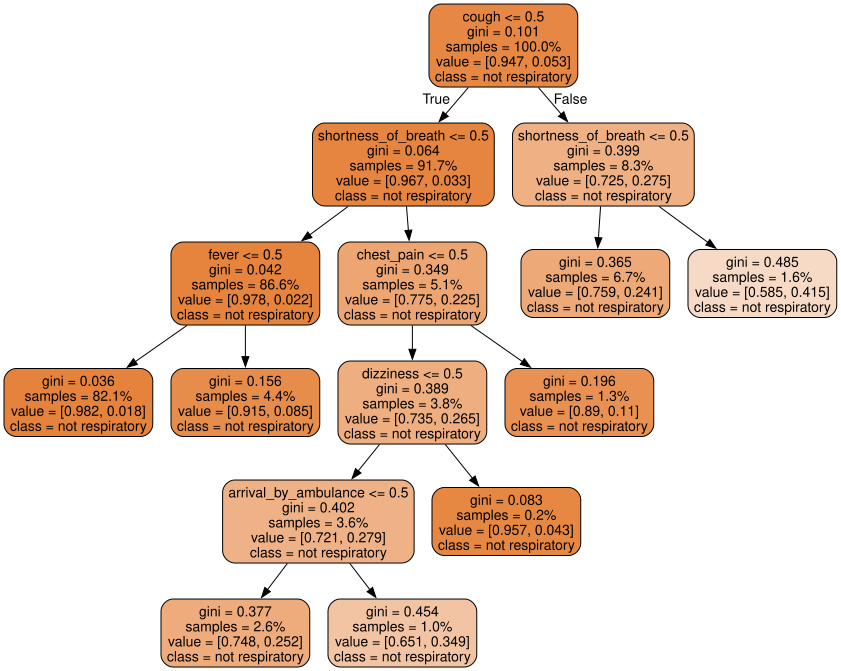

In [5]:
# Set outcome variable:
disease = 'respiratory'

## Construct outcome labels
y = (df['disease_group'] == disease).astype(int)
y_test = (test['disease_group'] == disease ).astype(int)
outcome = ['not ' + disease, disease]

## Set up tree classifier:
model = DecisionTreeClassifier(max_depth = 10, # Maximum tree depth
                              min_samples_leaf = 35, # Mininum cases per leaf
                              min_impurity_decrease = 1e-4, # Minimum impurity decrease to split a node
                              random_state = 100) # Random state for reproducibility

## Fit model to training data:
model.fit(X, y)

# Export the tree to Graphviz DOT format
from sklearn.tree import export_graphviz
dot_data = export_graphviz(
    model, 
    out_file=None, 
    feature_names=x_vars,
    class_names=outcome,
    filled=True, 
    proportion=True,
    rounded=True,
)

graph = graphviz.Source(dot_data)
graph

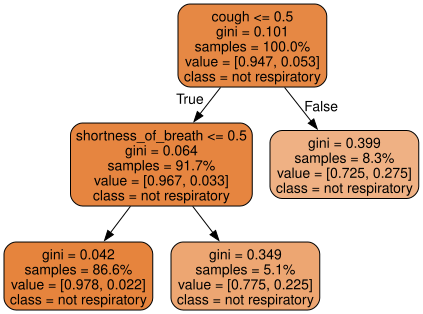

In [6]:
# Set outcome variable:
disease = 'respiratory'

## Construct outcome labels
y = (df['disease_group'] == disease).astype(int)
y_test = (test['disease_group'] == disease ).astype(int)
outcome = ['not ' + disease, disease]

## Set up tree classifier:
model = DecisionTreeClassifier(max_depth = 10, # Maximum tree depth
                              min_samples_leaf = 35, # Mininum cases per leaf
                              min_impurity_decrease = 1e-3, # Minimum impurity decrease to split a node
                              random_state = 100) # Random state for reproducibility

## Fit model to training data:
model.fit(X, y)

# Export the tree to Graphviz DOT format
from sklearn.tree import export_graphviz
dot_data = export_graphviz(
    model, 
    out_file=None, 
    feature_names=x_vars,
    class_names=outcome,
    filled=True, 
    proportion=True,
    rounded=True,
)

graph = graphviz.Source(dot_data)
graph

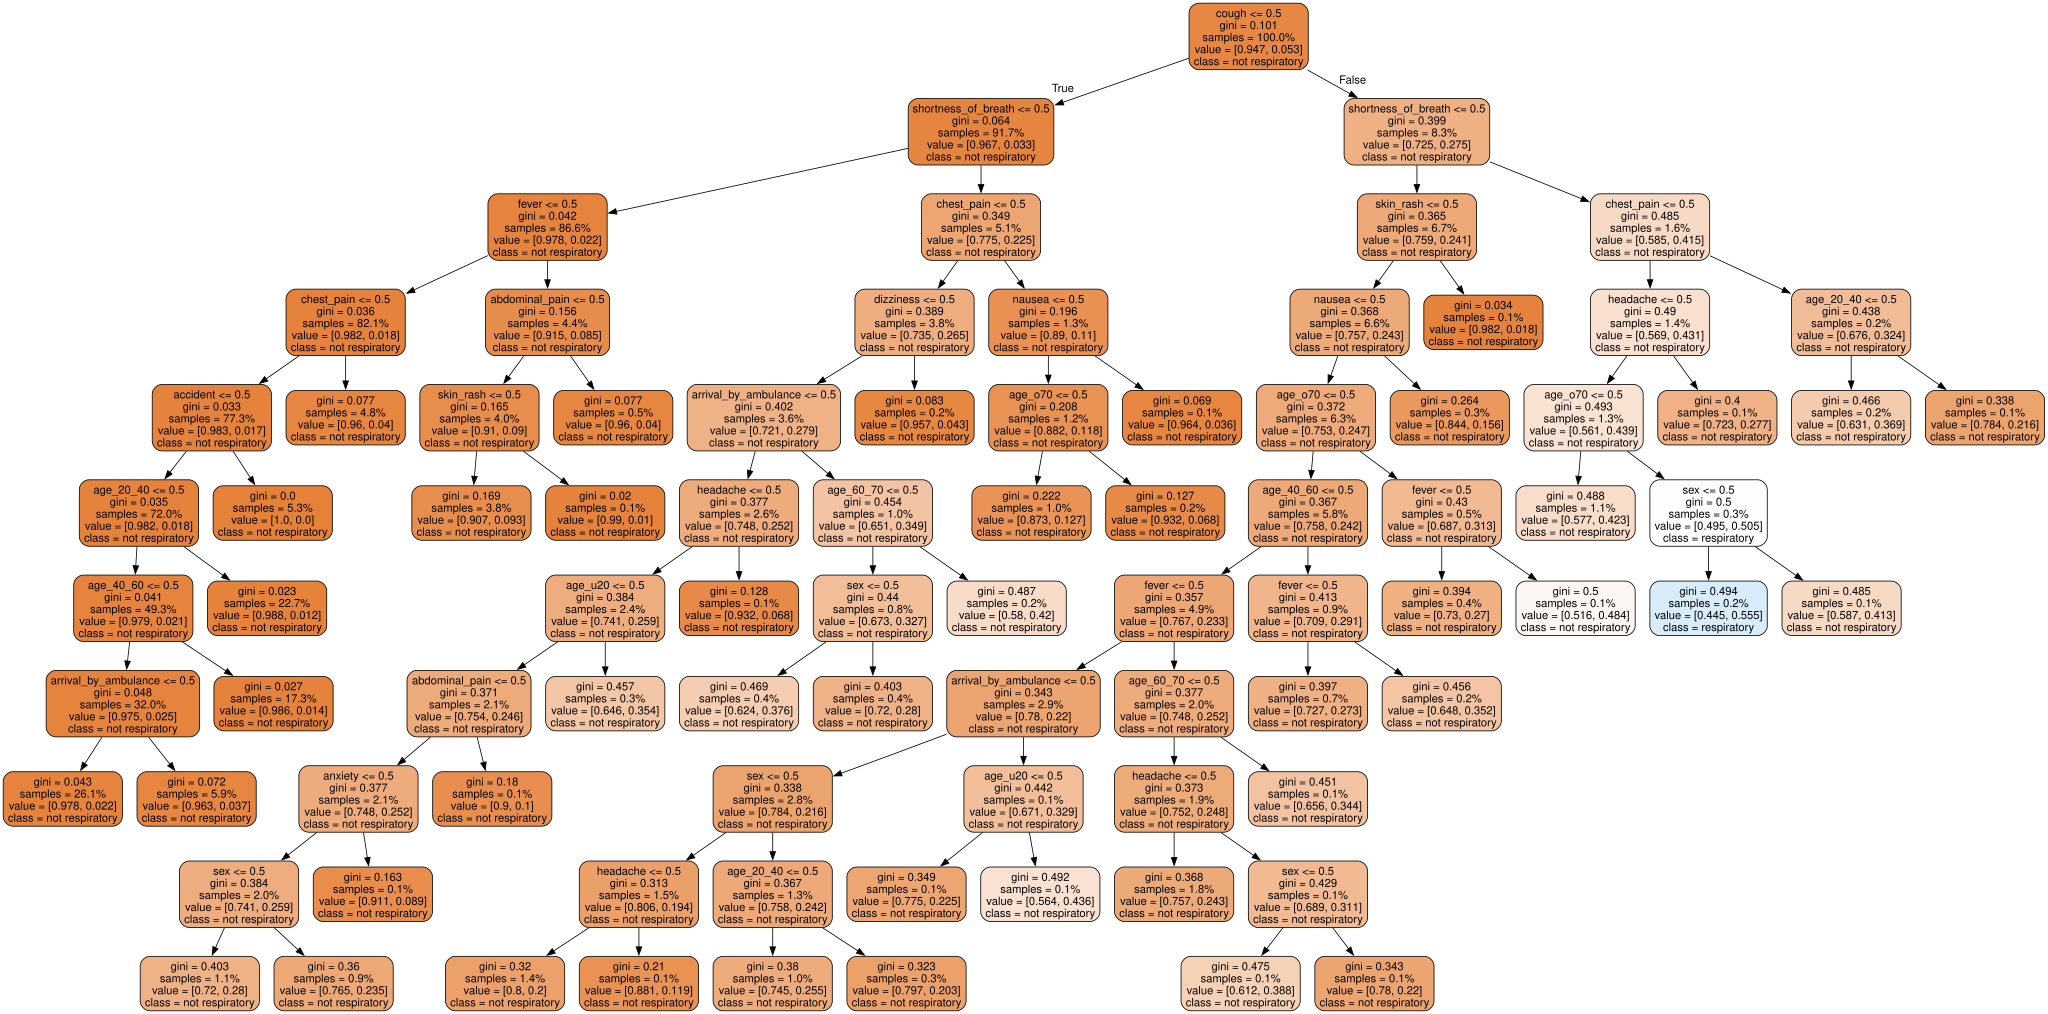

In [7]:
# Set outcome variable:
disease = 'respiratory'

## Construct outcome labels
y = (df['disease_group'] == disease).astype(int)
y_test = (test['disease_group'] == disease ).astype(int)
outcome = ['not ' + disease, disease]

## Set up tree classifier:
model = DecisionTreeClassifier(max_depth = 10, # Maximum tree depth
                              min_samples_leaf = 35, # Mininum cases per leaf
                              min_impurity_decrease = 1e-5, # Minimum impurity decrease to split a node
                              random_state = 100) # Random state for reproducibility

## Fit model to training data:
model.fit(X, y)

# Export the tree to Graphviz DOT format
from sklearn.tree import export_graphviz
dot_data = export_graphviz(
    model, 
    out_file=None, 
    feature_names=x_vars,
    class_names=outcome,
    filled=True, 
    proportion=True,
    rounded=True,
)

graph = graphviz.Source(dot_data)
graph

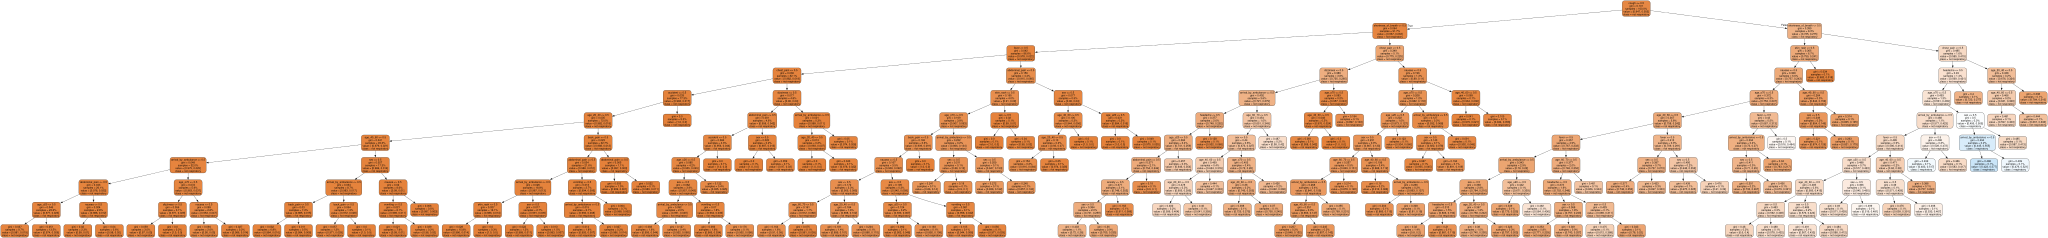

In [8]:
# Set outcome variable:
disease = 'respiratory'

## Construct outcome labels
y = (df['disease_group'] == disease).astype(int)
y_test = (test['disease_group'] == disease ).astype(int)
outcome = ['not ' + disease, disease]

## Set up tree classifier:
model = DecisionTreeClassifier(max_depth = 10, # Maximum tree depth
                              min_samples_leaf = 35, # Mininum cases per leaf
                              min_impurity_decrease = 1e-7, # Minimum impurity decrease to split a node
                              random_state = 100) # Random state for reproducibility

## Fit model to training data:
model.fit(X, y)

# Export the tree to Graphviz DOT format
from sklearn.tree import export_graphviz
dot_data = export_graphviz(
    model, 
    out_file=None, 
    feature_names=x_vars,
    class_names=outcome,
    filled=True, 
    proportion=True,
    rounded=True,
)

graph = graphviz.Source(dot_data)
graph

The above object is a **decision tree classifier**: It predicts class labels on the basis of covariates. At each **node** in the graph, there is a condition, like `cough<=.5`. Depending on how the case evaluates, we move left (`True`) or right (`False`) down the tree along the **edges**. At each node, we also see the probability mass function, conditional on the current information set. At the bottom of the tree are **terminal leaves** with hard classification predictions and the final proportions.

The tree classifier pictured in the previous code chunk provides the probability mass function over the labels "not respiratory" and "respiratory". It starts as 95% of patients not having a respiratory problem, and 5% having a respiratory problem. The first differential diagnosis question is, "Does the patient have a cough?" If they do have a cough, we update our estimate to .73/.27, and if not, we update to .97/.03. If you have a cough, shortness of breath, you reach the highest estimate, .59/.41.

This is exactly what conditional probability and conditional expectation are: We update our beliefs based on evidence, and that reshapes our posterior estimates of the probabilities of different outcomes.

The probabilities displayed by the tree are fitted conditional estimates: they are the training-data class proportions among patients reaching each node. They are useful for this lab, but they are not calibrated clinical risk estimates.

<div class="alert alert-block alert-warning">

Which combinations of symptoms make a respiratory disease the most likely explanation? The least likely?

The combinations of symptoms that make a respiratory disease the most likely explanation is cough and shortness of breath. This group has a 41.5% change of a respiratory diagnoses which is way higher than the overall base rate of 5.3%. Having a cough without shortness of breath already pushes the odds up to 24.1%. Respiratory disease is least likely if a patient has no cough, shortness of breath, or fever. This group's chance of having a respiratory disease drops to 1.8% This group is also the biggest group in the entire dataset with over 80% of patients.


Which variables does the tree exploit? 

The tree only uses six symptoms to make a decision. The tree uses cough, shortness of breath, fever, chest pain, dizziness, and ambulance arrival. Symptoms such as cough and shortness of breath are the most important because the tree checks them multiple times. Other symptoms such as vomiting, headache, skin rash and traits such as sex and age are ignored in this tree because they do not help distinguish respiratory cases from everything else.

Clearly explain how the tree is a representation of conditional updating, where we condition on reported symptoms to provide new probability estimates based on new information.

The root node gives the unconditional probability of respiratory disease which is 5.3% and this is the rate across the whole sample. Each split conditions on one symptom. If the patient has a cough, the estimate updates to 27.5% which is the rate of respiratory disease among coughing patients only. If the patient also has shortness of breath, the rate goes up to 41.5% which is the rate among patients with both symptoms. Each node's value is the probability of respiratory disease given everything we know about the patient's symptoms up to that point in the tree. The tree is a representation of conditional updating because we start with a prior probability and then we revise it downward through the tree as each new piece of symptom information narrows the reference group and produces a new posterior estimate.

Run the code again, but try values of 1e-3=0.001, 1e-5=0.00001 and 1e-7=0.0000001 for `min_impurity_decrease` to allow it to explore more complex explanations of the data. For each value of the `min_impurity_decrease` hyperparameter, find the terminal leaves with the lowest and highest probabilities of respiratory disease. How do these values vary with the complexity of the tree?

1e-3=0.001:
The terminal leaf with the lowest probability of respiratory disease is 2.2%, covering 86.6% of patients. The terminal leaf with the highest probability of respiratory disease is 27.5% and covers 8.3% of patients. This tree is the simpliest and only has three leaves and a depth of 2. The probabilities stay closer together and each leaf covers a fairly large group of patients.

1e-5=0.00001:
The terminal leaf with the lowest probability of respiratory disease is 0% which covers 5.3% of patients. The terminal leaf with the highest probability of respiratory disease is 55.5% which only covers 0.17% of patients. The values in this tree vary a lot more than they did in previous trees. This tree is far more complex and has 44 leaves and the depth is 10 and the leaves now cover much smaller groups of patients.

1e-7=0.0000001:
The terminal leaf with the lowest probability of respiratory disease is 0% and this only covers 0.05% of patients. The terminal leaf with the highest probability of respiratory disease is 57.8% and this only covers 0.10% of patients. The values for this tree vary even more because there are hundreds of leaves and the depth is 10. Both extreme leaves now only cover very tiny amount of the data and are now less reliable.


</div>

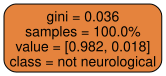

In [10]:
disease = 'neurological'

## Construct outcome labels
y = (df['disease_group'] == disease).astype(int)
y_test = (test['disease_group'] == disease ).astype(int)
outcome = ['not ' + disease, disease]

## Set up tree classifier:
model = DecisionTreeClassifier(max_depth = 10, # Maximum tree depth
                              min_samples_leaf = 35, # Mininum cases per leaf
                              min_impurity_decrease = 1e-3, # Minimum impurity decrease to split a node
                              random_state = 100) # Random state for reproducibility

## Fit model to training data:
model.fit(X, y)

# Export the tree to Graphviz DOT format
from sklearn.tree import export_graphviz
dot_data = export_graphviz(
    model, 
    out_file=None, 
    feature_names=x_vars,
    class_names=outcome,
    filled=True, 
    proportion=True,
    rounded=True,
)

graph = graphviz.Source(dot_data)
graph

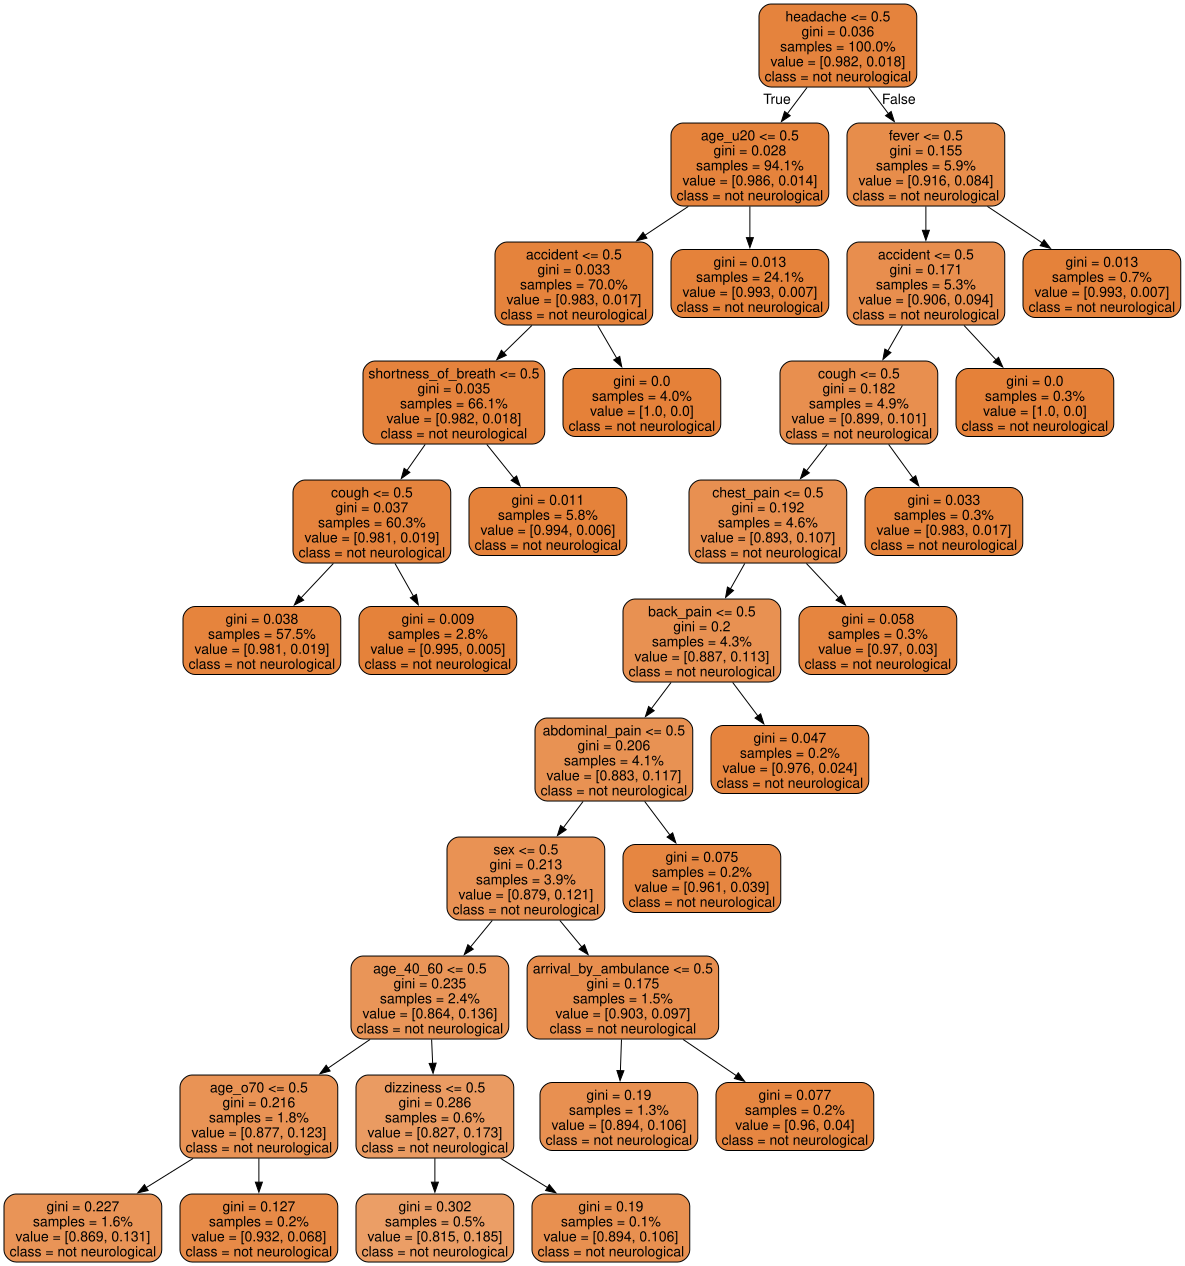

In [11]:
disease = 'neurological'

## Construct outcome labels
y = (df['disease_group'] == disease).astype(int)
y_test = (test['disease_group'] == disease ).astype(int)
outcome = ['not ' + disease, disease]

## Set up tree classifier:
model = DecisionTreeClassifier(max_depth = 10, # Maximum tree depth
                              min_samples_leaf = 35, # Mininum cases per leaf
                              min_impurity_decrease = 1e-5, # Minimum impurity decrease to split a node
                              random_state = 100) # Random state for reproducibility

## Fit model to training data:
model.fit(X, y)

# Export the tree to Graphviz DOT format
from sklearn.tree import export_graphviz
dot_data = export_graphviz(
    model, 
    out_file=None, 
    feature_names=x_vars,
    class_names=outcome,
    filled=True, 
    proportion=True,
    rounded=True,
)

graph = graphviz.Source(dot_data)
graph

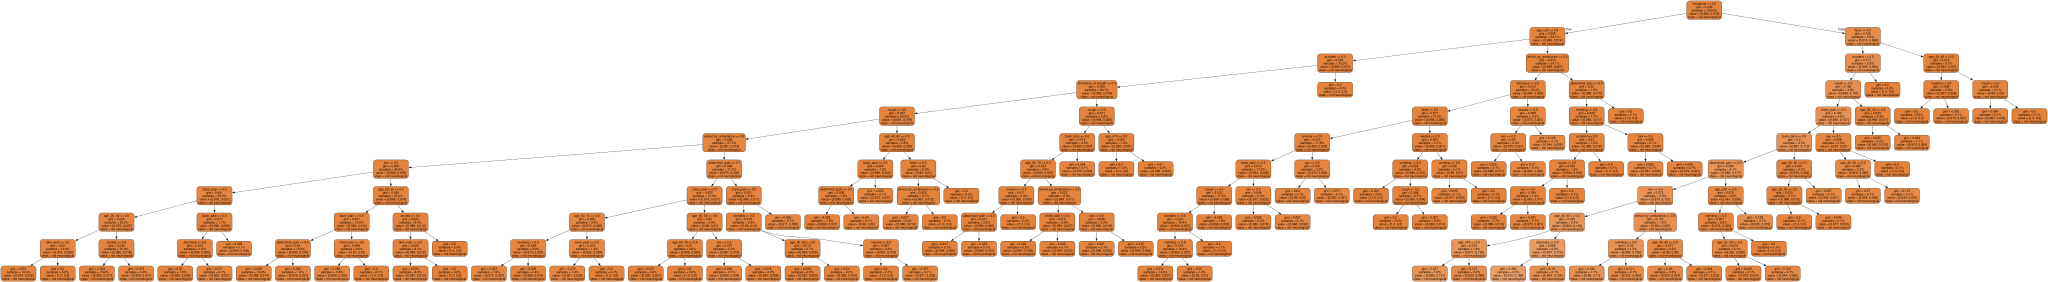

In [12]:
disease = 'neurological'

## Construct outcome labels
y = (df['disease_group'] == disease).astype(int)
y_test = (test['disease_group'] == disease ).astype(int)
outcome = ['not ' + disease, disease]

## Set up tree classifier:
model = DecisionTreeClassifier(max_depth = 10, # Maximum tree depth
                              min_samples_leaf = 35, # Mininum cases per leaf
                              min_impurity_decrease = 1e-7, # Minimum impurity decrease to split a node
                              random_state = 100) # Random state for reproducibility

## Fit model to training data:
model.fit(X, y)

# Export the tree to Graphviz DOT format
from sklearn.tree import export_graphviz
dot_data = export_graphviz(
    model, 
    out_file=None, 
    feature_names=x_vars,
    class_names=outcome,
    filled=True, 
    proportion=True,
    rounded=True,
)

graph = graphviz.Source(dot_data)
graph

<div class="alert alert-block alert-warning">

Repeat the previous step with `disease = 'neurological'` and `min_impurity_decrease = 1e-3`. What variables are used in the tree? Which variables raise or lower the predicted probability of a neurological diagnosis?

The most dominant variable is headache. This symptom is the very first split in both the 1e-5 tree and the 1e-7 tree. Accident lowers the probability even when headache is present, a headache right after an accident reads as trauma, not a neurological condition on its own. Age 40-60 raises the probability slightly within the headache branch. 

`Run the code again, but try values of 1e-3=0.001, 1e-5=0.00001 and 1e-7=0.0000001 for `min_impurity_decrease` to allow it to explore more complex explanations of the data. For each value of the `min_impurity_decrease` hyperparameter, find the terminal leaves with the lowest and highest probabilities of respiratory disease. How do these values vary with the complexity of the tree?`

1e-3=0.001:
This tree does not split at all and there is only one node. No variables are used in this tree. This is because the neurological base rate is only 1.8% which means that the root is already too pure for any single split to clear the 1e-3 threshold. In this tree every patient gets the same estimate of 1.8%

1e-5=0.00001::
This tree mainly splits on headache, then age under 20, accident, shortness of breath, cough, fever, chest_pain, back pain, abdominal pain, sex, age 40 to 60, age over 70, dizziness, and arrival by ambulance. This tree has 17 leaves and a depth of 10. The leaf with the lowest probability of neurological disease is 0% and covers 0.35% of patients. The leaf with the highest probability is 18.5% and covers 0.51% of patients. 

1e-7=0.0000001:
This tree comes out to be very large with lieky close to 100 leaves and it adds more variables. This tree adds nausea, vomiting, anxiety, skin rash, and other age categories. The lowest leaf is still 0% and now covers just 0.05% of patients. The highest leaf is unchanged from the 1e-5 tree and is still 18.5%.

</div>

## Step 2:

In step 1, we tried to predict whether a patient has a single condition or not. Now, we want to predict the entire probability mass function.

The code block sets `y = df['disease_group']` and `outcome = df['disease_group'].unique()`, and runs a similar analysis. The result is now a fitted differential diagnosis: an estimated probability mass function over the labels and a hard classification label. For readability, we set `max_depth = 3`.

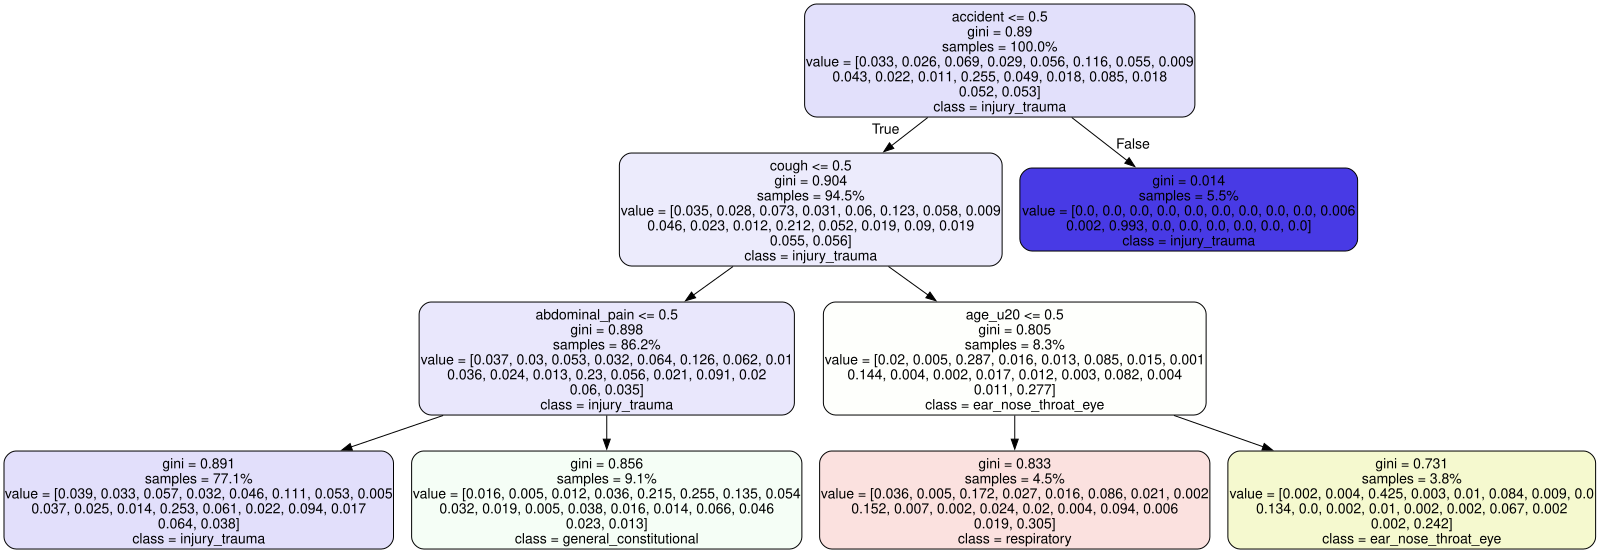

In [13]:
# Set outcome variable:
y = df['disease_group']
## Set up tree classifier:
model = DecisionTreeClassifier(max_depth = 3, # Maximum tree depth
                              min_samples_leaf = 35, # Mininum cases per leaf
                              min_impurity_decrease = 1e-4, # Minimum impurity decrease to split a node
                              random_state = 100) # Random state for reproducibility

## Fit model to training data:
model.fit(X, y)


# Export the tree to Graphviz DOT format
from sklearn.tree import export_graphviz
dot_data = export_graphviz(
    model, 
    out_file=None, 
    feature_names=x_vars,
    class_names=model.classes_,
    filled=True, 
    proportion=True,
    rounded=True,
)

graph = graphviz.Source(dot_data)
graph

<div class="alert alert-block alert-warning">

Which diseases are predicted as hard classifications in the tree? For those labels, does the probability of that disease exceed even a moderate value like .3 or .5, or not? Why might this be a concern?

The diseases predicted as hard classifications are injury trauma, general constitutional, respiratory, and ear nose throat eye. Only one label passes .5, the accident leaf, predicted injury trauma at 99.3%. The other four all fall below .5 and most fall below .3 as well. This is concerning because a hard classification presents one label as the answer, but for 4 of the 5 leaves, that label is actually correct less than half of the time. If someone were to read the predicted class without seeing the full probability breakdown, they would likely be misled into thinking the model is far more accurate than it actual is.

Which labels have the highest or lowest probabilities for the predicted disease class labels? 

The label with the highest probability is injury trauma at 99.3% in the accident leaf. The label with the lowest probability is also injury trauma at 25.3% in the largest leaf which is no accident, no cough, no abdominal pain. 

Which conditions and values are used in the tree?

The tree uses four variables that are all split at a value of 0.5 because they are binary indicators. The four bariables are accident, cough, abdominal pain, and age under 20.

Even if the probabilities for each terminal leaf remain fairly small in absolute terms, why can a differential diagnosis tool like this still be useful for doctors?

Even though the only leaf that cleared 50% was the accident one, this tool still gives doctors a full ranked list of probabilities across all 18 disease categories. This allows doctors to see which categories are most likely given the reported symptoms. The doctor can prioritize tests or ask questions related to those categories instead of treating one label as a final diagnosis. This tool should be used as prioritization and for testing and should not be a replacement for the doctor's own judgement. 

</div>